# Limit Order Book — Exploratory Data Analysis

This notebook loads `lob_data_in_sample.parquet` and `daily_data_in_sample.parquet` from the `../data/` directory and performs a structured EDA covering:

1. [Data Loading & Schema](#1.-Data-Loading-&-Schema)
2. [Dataset Coverage](#2.-Dataset-Coverage)
3. [Missing Data Analysis](#3.-Missing-Data-Analysis)
4. [LOB Snapshot Visualization](#4.-LOB-Snapshot-Visualization)
5. [Mid-Price & Bid-Ask Spread](#5.-Mid-Price-&-Bid-Ask-Spread)
6. [Intraday Patterns](#6.-Intraday-Patterns)
7. [Volume Structure & Order Imbalance](#7.-Volume-Structure-&-Order-Imbalance)
8. [Price Level Spacing (Tick Structure)](#8.-Price-Level-Spacing)
9. [Daily Data EDA](#9.-Daily-Data-EDA)
10. [Cross-Asset Overview](#10.-Cross-Asset-Overview)

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)

# ── configuration ────────────────────────────────────────────────────────────
DATA_DIR = "../data"
ASSET_ID = "A000568"  # single-asset deep dives
DAY_ID = "D001"  # reference trading day
SNAP_TIME = "10:00:00"  # reference snapshot timestamp
N_LEVELS = 10

ASK_PRICE_COLS = [f"ask_price_{i}" for i in range(1, N_LEVELS + 1)]
BID_PRICE_COLS = [f"bid_price_{i}" for i in range(1, N_LEVELS + 1)]
ASK_VOL_COLS = [f"ask_volume_{i}" for i in range(1, N_LEVELS + 1)]
BID_VOL_COLS = [f"bid_volume_{i}" for i in range(1, N_LEVELS + 1)]
ALL_PRICE_COLS = ASK_PRICE_COLS + BID_PRICE_COLS
ALL_VOL_COLS = ASK_VOL_COLS + BID_VOL_COLS

---
## 1. Data Loading & Schema

In [2]:
lob = pd.read_parquet(f"{DATA_DIR}/lob_data_in_sample.parquet")
daily = pd.read_parquet(f"{DATA_DIR}/daily_data_in_sample.parquet")

print(f"LOB shape   : {lob.shape[0]:,} rows × {lob.shape[1]} columns")
print(f"Daily shape : {daily.shape[0]:,} rows × {daily.shape[1]} columns")

LOB shape   : 24,810,697 rows × 43 columns
Daily shape : 1,060,121 rows × 10 columns


In [3]:
print("── LOB columns & dtypes ─────────────────────────────────")
print(lob.dtypes.to_string())
print()
print("── Daily columns & dtypes ───────────────────────────────")
print(daily.dtypes.to_string())

── LOB columns & dtypes ─────────────────────────────────
asset_id          object
trade_day_id      object
time              object
ask_price_1      float32
ask_price_2      float32
ask_price_3      float32
ask_price_4      float32
ask_price_5      float32
ask_price_6      float32
ask_price_7      float32
ask_price_8      float32
ask_price_9      float32
ask_price_10     float32
bid_price_1      float32
bid_price_2      float32
bid_price_3      float32
bid_price_4      float32
bid_price_5      float32
bid_price_6      float32
bid_price_7      float32
bid_price_8      float32
bid_price_9      float32
bid_price_10     float32
ask_volume_1     float32
ask_volume_2     float32
ask_volume_3     float32
ask_volume_4     float32
ask_volume_5     float32
ask_volume_6     float32
ask_volume_7     float32
ask_volume_8     float32
ask_volume_9     float32
ask_volume_10    float32
bid_volume_1     float32
bid_volume_2     float32
bid_volume_3     float32
bid_volume_4     float32
bid_volume_5     

In [4]:
print("LOB — first 5 rows")
lob.head(5)

LOB — first 5 rows


,asset_id,trade_day_id,time,ask_price_1,ask_price_2,ask_price_3,ask_price_4,ask_price_5,ask_price_6,ask_price_7,...,bid_volume_1,bid_volume_2,bid_volume_3,bid_volume_4,bid_volume_5,bid_volume_6,bid_volume_7,bid_volume_8,bid_volume_9,bid_volume_10
0,A000118,D001,09:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A001498,D001,09:40:00,39.50,39.570000,39.779999,39.919998,39.93,39.950001,40.169998,...,600.0,542.0,300.0,1622.0,300.0,300.0,300.0,600.0,400.0,200.0
2,A000568,D001,09:40:00,4.54,4.550000,4.560000,4.570000,4.58,4.590000,4.600000,...,14000.0,17500.0,17100.0,101800.0,54600.0,144700.0,16000.0,4000.0,97800.0,23000.0
3,A001439,D001,09:40:00,7.29,7.300000,7.310000,7.320000,7.33,7.340000,7.350000,...,1000.0,6127.0,3444.0,8000.0,6000.0,8460.0,2000.0,1900.0,1000.0,1000.0
4,A000506,D001,09:40:00,18.51,18.549999,18.559999,18.570000,18.58,18.590000,18.600000,...,1939.0,3500.0,4000.0,500.0,3000.0,7500.0,6000.0,800.0,7500.0,500.0


In [5]:
print("Daily — first 5 rows")
daily.head(5)

Daily — first 5 rows


,asset_id,trade_day_id,open,high,low,close,volume,amount,adj_factor,vwap_0930_0935
0,A000651,D003,7.96,8.00,7.94,7.98,213222.43,169924.263,1.050479,7.991514
1,A001814,D003,14.20,14.50,13.97,14.05,227277.43,320899.519,1.004863,14.310266
2,A000919,D003,7.28,7.39,7.12,7.22,596525.95,432825.878,1.010924,7.346752
3,A000124,D003,15.78,15.83,15.27,15.55,42742.97,65978.957,1.044115,15.582191
4,A000474,D003,2.91,2.93,2.89,2.91,570043.02,165879.507,1.034483,2.910479


In [6]:
lob.describe().T

,count,mean,std,min,25%,50%,75%,max
ask_price_1,24615329.0,25.625450,5.387754e+01,0.00,6.91,13.46,26.750000,2.046000e+03
ask_price_2,24610545.0,25.371925,5.370491e+01,0.00,6.77,13.30,26.520000,2.047990e+03
ask_price_3,24347240.0,25.662157,5.394538e+01,0.30,6.93,13.48,26.780001,2.048000e+03
ask_price_4,24342676.0,25.683645,5.396615e+01,0.31,6.95,13.50,26.799999,2.048010e+03
ask_price_5,24337792.0,25.706179,5.398792e+01,0.32,6.96,13.51,26.830000,2.049900e+03
ask_price_6,24331809.0,25.730165,5.401093e+01,0.33,6.97,13.53,26.850000,2.049980e+03
ask_price_7,24324905.0,25.755352,5.403556e+01,0.34,6.98,13.55,26.879999,2.049990e+03
ask_price_8,24314691.0,25.783979,5.406351e+01,0.35,7.00,13.56,26.900000,2.050000e+03
ask_price_9,24302813.0,25.814339,5.409310e+01,0.36,7.02,13.58,26.940001,2.050100e+03
ask_price_10,24286968.0,25.848677,5.412671e+01,0.38,7.04,13.60,26.969999,2.050500e+03


---
## 2. Dataset Coverage

Key dimensions: how many assets, trading days, and intraday timestamps are present, and how uniformly the panel is populated.

In [7]:
n_assets = lob["asset_id"].nunique()
n_days = lob["trade_day_id"].nunique()
n_times = lob["time"].nunique()
intraday_ts = sorted(lob["time"].unique())

print(f"Unique assets        : {n_assets:,}")
print(f"Trading days         : {n_days:,}  ({DAY_ID} … D{n_days:03d})")
print(f"Intraday timestamps  : {n_times}  ({intraday_ts[0]} → {intraday_ts[-1]}, 10-min bars)")
print(f"  AM session : {intraday_ts[0]} – {intraday_ts[10]}")
print(f"  PM session : {intraday_ts[11]} – {intraday_ts[-1]}")
print()
print(
    f"Max theoretical rows : {n_assets:,} × {n_days:,} × {n_times} = {n_assets * n_days * n_times:,}"
)
print(
    f"Actual rows          : {len(lob):,}  ({len(lob) / (n_assets * n_days * n_times) * 100:.1f}% fill rate)"
)

Unique assets        : 2,270
Trading days         : 484  (D001 … D484)
Intraday timestamps  : 24  (09:40:00 → 15:00:00, 10-min bars)
  AM session : 09:40:00 – 11:20:00
  PM session : 13:00:00 – 15:00:00

Max theoretical rows : 2,270 × 484 × 24 = 26,368,320
Actual rows          : 24,810,697  (94.1% fill rate)


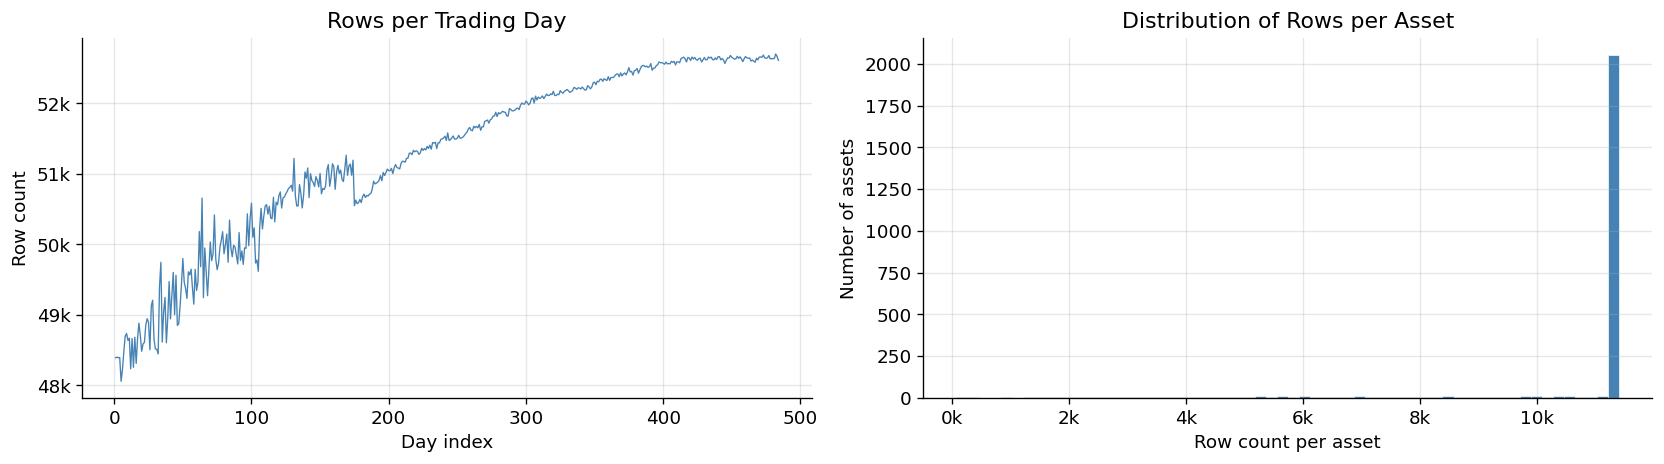

In [8]:
rows_per_day = lob.groupby("trade_day_id").size().reset_index(name="rows")
rows_per_day["day_num"] = rows_per_day["trade_day_id"].str[1:].astype(int)
rows_per_day = rows_per_day.sort_values("day_num")

rows_per_asset = lob.groupby("asset_id").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# rows per day
axes[0].plot(rows_per_day["day_num"], rows_per_day["rows"], lw=0.8, color="steelblue")
axes[0].set_title("Rows per Trading Day")
axes[0].set_xlabel("Day index")
axes[0].set_ylabel("Row count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}k"))

# rows per asset
axes[1].hist(rows_per_asset, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[1].set_title("Distribution of Rows per Asset")
axes[1].set_xlabel("Row count per asset")
axes[1].set_ylabel("Number of assets")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}k"))

plt.tight_layout()
plt.show()

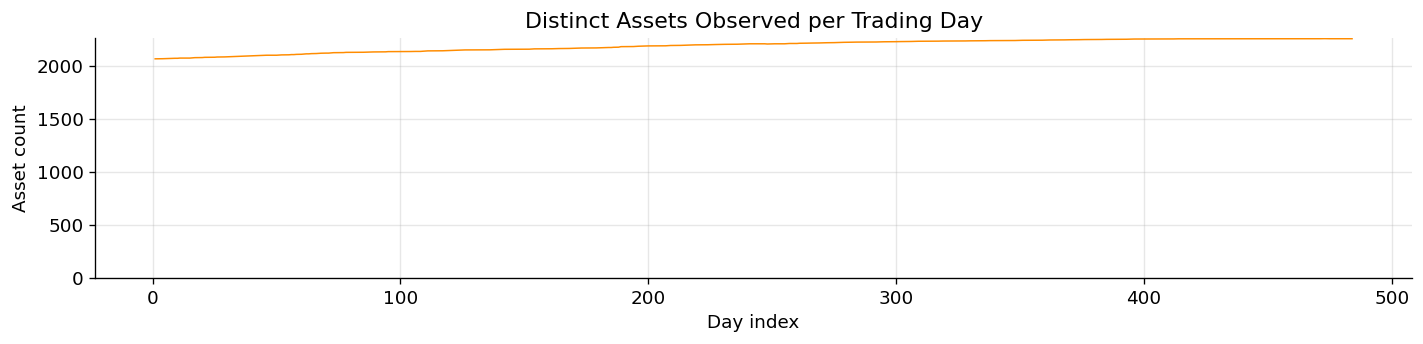

count     484.000000
mean     2193.256198
std        57.781487
min      2068.000000
25%      2149.000000
50%      2209.500000
75%      2246.000000
max      2259.000000


In [9]:
# Assets observed per day
assets_per_day = lob.groupby("trade_day_id")["asset_id"].nunique().reset_index(name="n_assets")
assets_per_day["day_num"] = assets_per_day["trade_day_id"].str[1:].astype(int)
assets_per_day = assets_per_day.sort_values("day_num")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(assets_per_day["day_num"], assets_per_day["n_assets"], lw=0.9, color="darkorange")
ax.set_title("Distinct Assets Observed per Trading Day")
ax.set_xlabel("Day index")
ax.set_ylabel("Asset count")
ax.set_ylim(0)
plt.tight_layout()
plt.show()

print(assets_per_day["n_assets"].describe().to_string())

---
## 3. Missing Data Analysis

NaN values are expected to increase with level depth: deep levels are sparse when the book is thin.

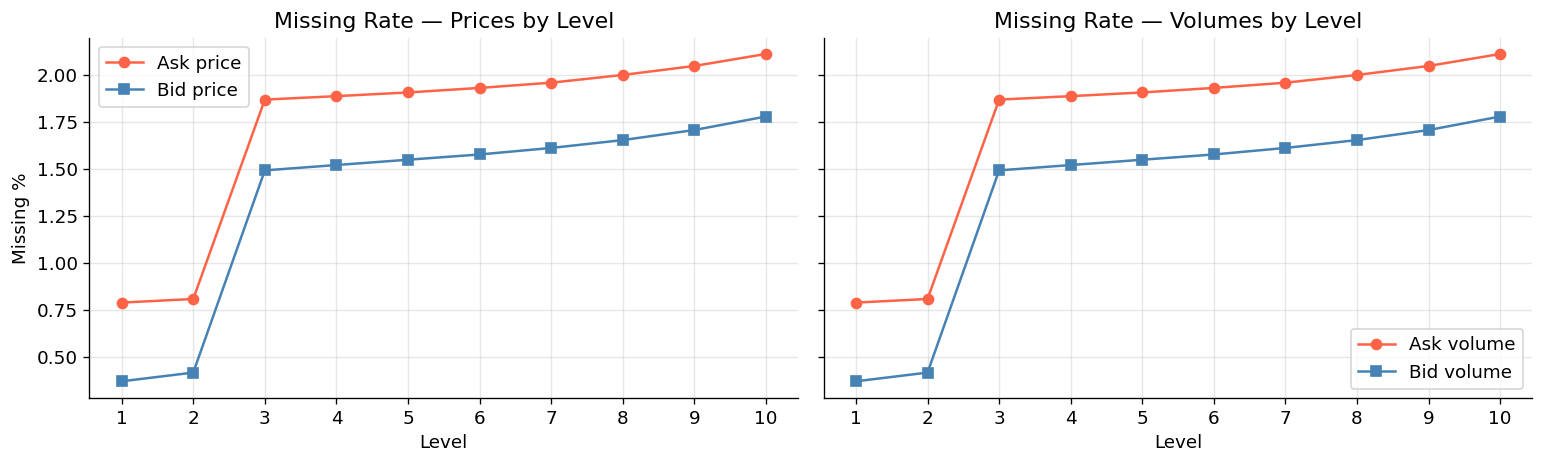

Ask L1 missing: 0.79%   Bid L1 missing: 0.37%
Ask L10 missing: 2.11%  Bid L10 missing: 1.78%


In [10]:
null_pct = lob[ALL_PRICE_COLS + ALL_VOL_COLS].isnull().mean() * 100

ask_price_null = null_pct[ASK_PRICE_COLS].values
bid_price_null = null_pct[BID_PRICE_COLS].values
ask_vol_null = null_pct[ASK_VOL_COLS].values
bid_vol_null = null_pct[BID_VOL_COLS].values
levels = np.arange(1, N_LEVELS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

axes[0].plot(levels, ask_price_null, "o-", label="Ask price", color="tomato")
axes[0].plot(levels, bid_price_null, "s-", label="Bid price", color="steelblue")
axes[0].set_title("Missing Rate — Prices by Level")
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Missing %")
axes[0].set_xticks(levels)
axes[0].legend()

axes[1].plot(levels, ask_vol_null, "o-", label="Ask volume", color="tomato")
axes[1].plot(levels, bid_vol_null, "s-", label="Bid volume", color="steelblue")
axes[1].set_title("Missing Rate — Volumes by Level")
axes[1].set_xlabel("Level")
axes[1].set_xticks(levels)
axes[1].legend()

plt.tight_layout()
plt.show()

print(
    "Ask L1 missing: {:.2f}%   Bid L1 missing: {:.2f}%".format(ask_price_null[0], bid_price_null[0])
)
print(
    "Ask L10 missing: {:.2f}%  Bid L10 missing: {:.2f}%".format(
        ask_price_null[-1], bid_price_null[-1]
    )
)

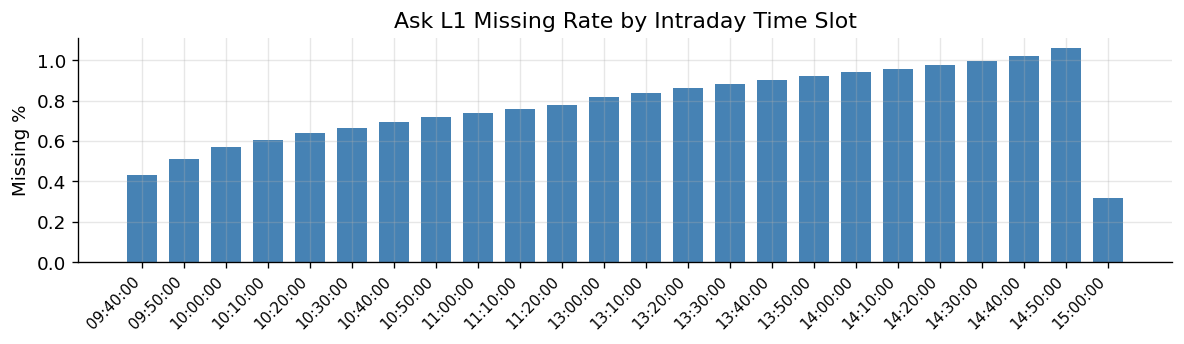

In [11]:
# Missing rate at L1 broken down by time-of-day
l1_null_by_time = lob.groupby("time")["ask_price_1"].apply(lambda s: s.isnull().mean() * 100)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(l1_null_by_time)), l1_null_by_time.values, color="steelblue", width=0.7)
ax.set_xticks(range(len(l1_null_by_time)))
ax.set_xticklabels(l1_null_by_time.index, rotation=45, ha="right", fontsize=9)
ax.set_title("Ask L1 Missing Rate by Intraday Time Slot")
ax.set_ylabel("Missing %")
plt.tight_layout()
plt.show()

---
## 4. LOB Snapshot Visualization

The canonical representation of a limit order book at a single point in time: bid orders (buyers) on the left, ask orders (sellers) on the right, with price on the y-axis.

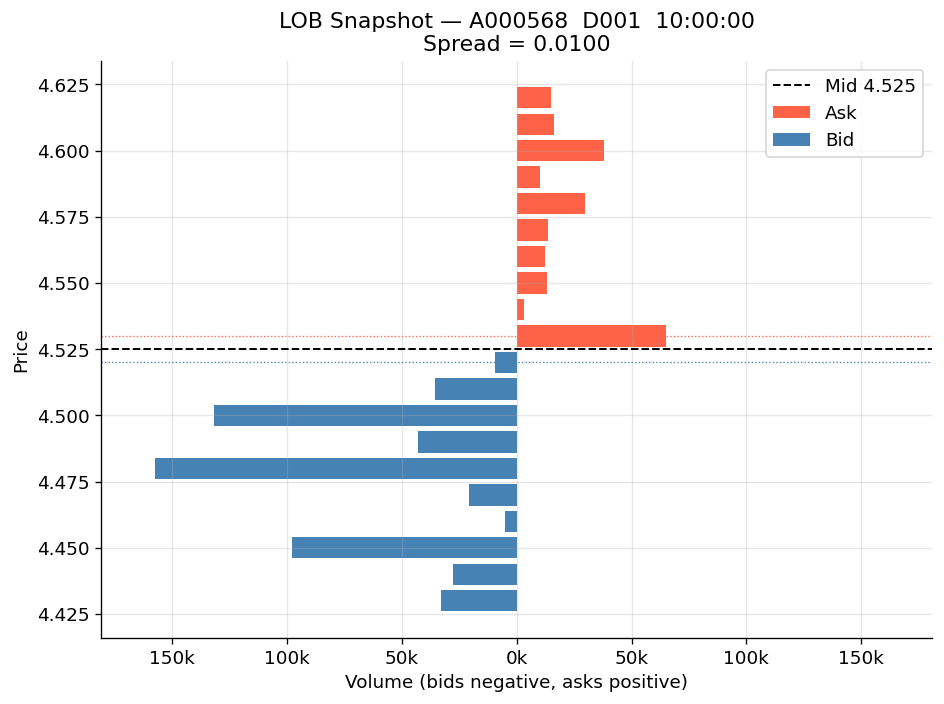

In [12]:
snap = lob[
    (lob["asset_id"] == ASSET_ID) & (lob["trade_day_id"] == DAY_ID) & (lob["time"] == SNAP_TIME)
].iloc[0]

ask_prices = snap[ASK_PRICE_COLS].values.astype(float)
bid_prices = snap[BID_PRICE_COLS].values.astype(float)
ask_vols = snap[ASK_VOL_COLS].values.astype(float)
bid_vols = snap[BID_VOL_COLS].values.astype(float)

mid_price = (ask_prices[0] + bid_prices[0]) / 2
spread = ask_prices[0] - bid_prices[0]

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(ask_prices, ask_vols, height=0.008, color="tomato", label="Ask", align="center")
ax.barh(bid_prices, -bid_vols, height=0.008, color="steelblue", label="Bid", align="center")

ax.axhline(mid_price, color="black", lw=1.2, ls="--", label=f"Mid {mid_price:.3f}")
ax.axhline(ask_prices[0], color="tomato", lw=0.8, ls=":")
ax.axhline(bid_prices[0], color="steelblue", lw=0.8, ls=":")

max_vol = max(np.nanmax(ask_vols), np.nanmax(bid_vols))
ax.set_xlim(-max_vol * 1.15, max_vol * 1.15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{abs(x) / 1e3:.0f}k"))
ax.set_xlabel("Volume (bids negative, asks positive)")
ax.set_ylabel("Price")
ax.set_title(f"LOB Snapshot — {ASSET_ID}  {DAY_ID}  {SNAP_TIME}\nSpread = {spread:.4f}")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

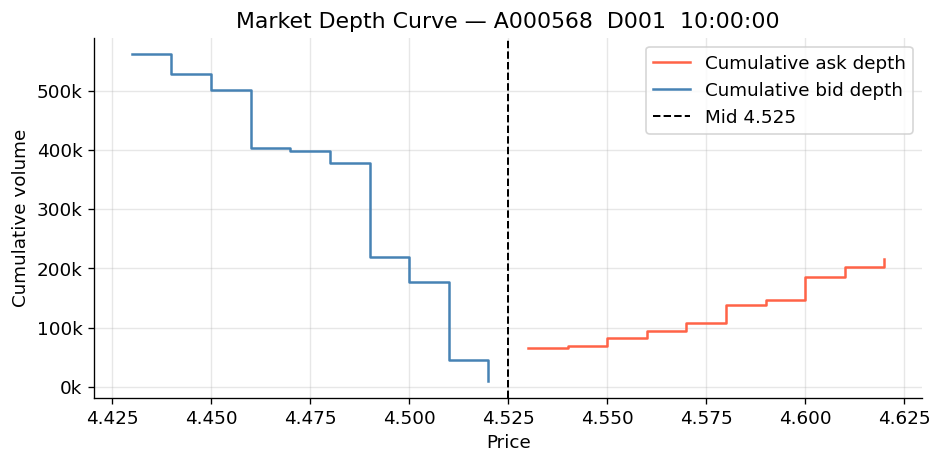

In [13]:
# Cumulative depth chart (market depth curve)
cum_ask_vol = np.nancumsum(ask_vols)
cum_bid_vol = np.nancumsum(bid_vols)

fig, ax = plt.subplots(figsize=(8, 4))
ax.step(ask_prices, cum_ask_vol, where="post", color="tomato", label="Cumulative ask depth")
ax.step(
    bid_prices[::-1],
    cum_bid_vol[::-1],
    where="post",
    color="steelblue",
    label="Cumulative bid depth",
)
ax.axvline(mid_price, color="black", lw=1.2, ls="--", label=f"Mid {mid_price:.3f}")
ax.set_xlabel("Price")
ax.set_ylabel("Cumulative volume")
ax.set_title(f"Market Depth Curve — {ASSET_ID}  {DAY_ID}  {SNAP_TIME}")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}k"))
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Mid-Price & Bid-Ask Spread

The mid-price is the reference price for most LOB-based models. The spread is the primary measure of market liquidity.

In [14]:
# Derive mid-price and spread across the full dataset
lob["mid_price"] = (lob["ask_price_1"] + lob["bid_price_1"]) / 2
lob["spread"] = lob["ask_price_1"] - lob["bid_price_1"]
lob["rel_spread"] = lob["spread"] / lob["mid_price"]  # relative spread (bps × 10000)

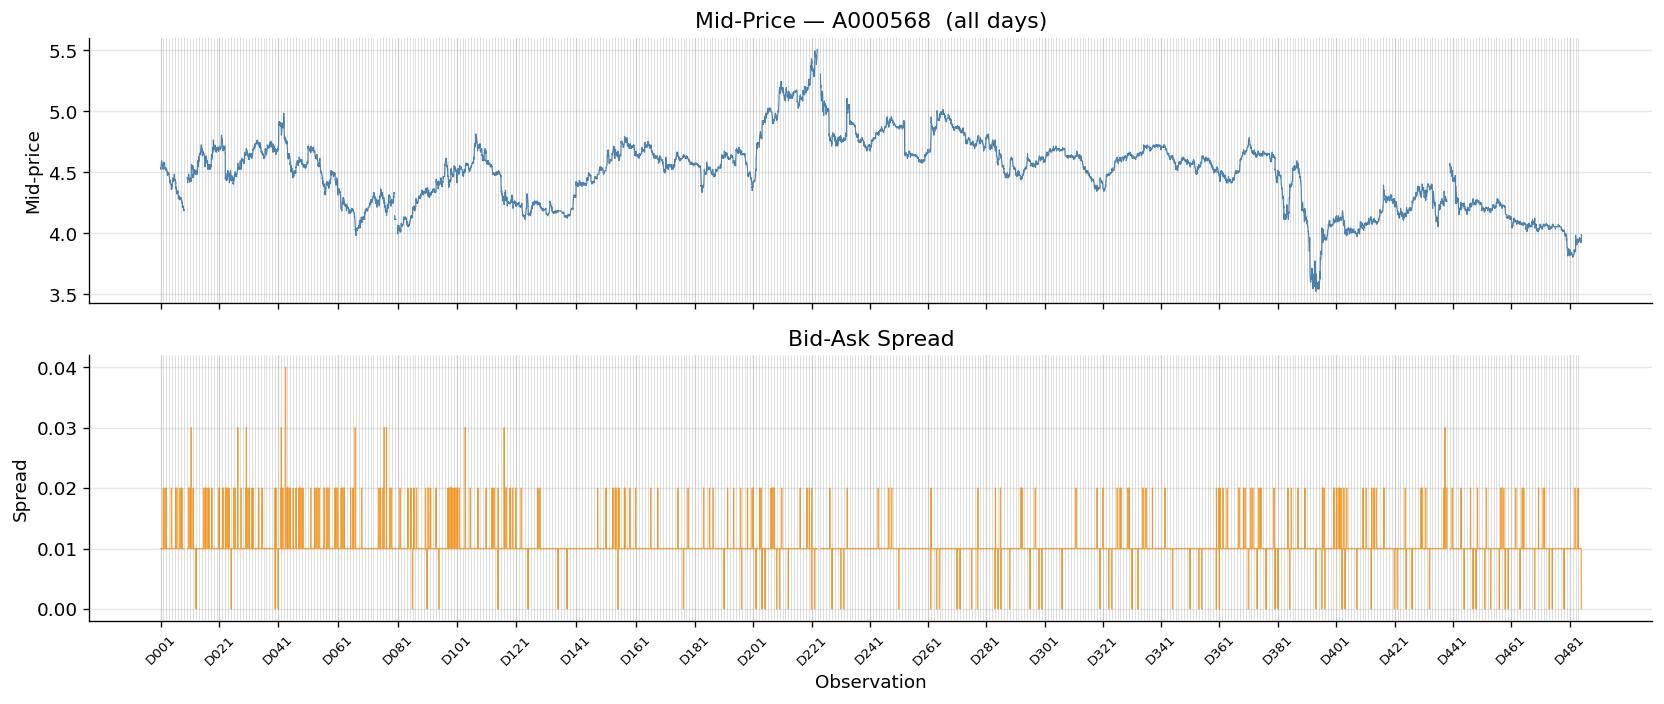

In [15]:
# Mid-price time series for one asset across multiple days
asset_lob = lob[lob["asset_id"] == ASSET_ID].copy()
asset_lob["day_num"] = asset_lob["trade_day_id"].str[1:].astype(int)
asset_lob = asset_lob.sort_values(["day_num", "time"])
asset_lob["obs_index"] = range(len(asset_lob))

# Build tick labels for day boundaries
day_start_idx = asset_lob.groupby("day_num")["obs_index"].first()
tick_positions = day_start_idx.values[::20]
tick_labels = [f"D{d:03d}" for d in day_start_idx.index[::20]]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(asset_lob["obs_index"], asset_lob["mid_price"], lw=0.7, color="steelblue")
axes[0].set_title(f"Mid-Price — {ASSET_ID}  (all days)")
axes[0].set_ylabel("Mid-price")

axes[1].plot(asset_lob["obs_index"], asset_lob["spread"], lw=0.7, color="darkorange", alpha=0.8)
axes[1].set_title("Bid-Ask Spread")
axes[1].set_ylabel("Spread")
axes[1].set_xlabel("Observation")
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, fontsize=8, rotation=45)

for ax in axes:
    for pos in day_start_idx.values:
        ax.axvline(pos, color="grey", lw=0.3, alpha=0.5)

plt.tight_layout()
plt.show()

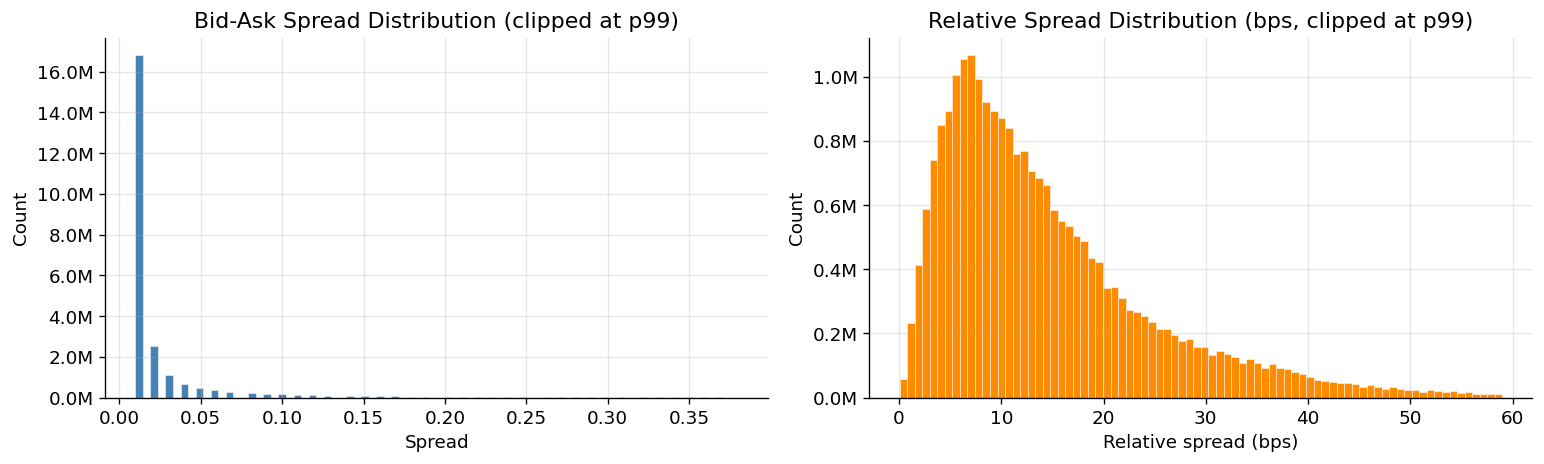

Spread — median: 0.0100  mean: 0.0323  p99: 0.3800
Rel spread — median: 11.67 bps


In [16]:
# Spread distribution across all assets and days (filter obvious outliers: spread > 0)
valid_spread = lob["spread"].dropna()
valid_spread = valid_spread[valid_spread > 0]

# Clip at 99th percentile for display
p99 = valid_spread.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(
    valid_spread[valid_spread <= p99],
    bins=80,
    color="steelblue",
    edgecolor="white",
    lw=0.3,
)
axes[0].set_title("Bid-Ask Spread Distribution (clipped at p99)")
axes[0].set_xlabel("Spread")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1e6:.1f}M"))

rel_spread = lob["rel_spread"].dropna()
rel_spread = rel_spread[(rel_spread > 0) & (rel_spread < rel_spread.quantile(0.99))]
axes[1].hist(rel_spread * 10000, bins=80, color="darkorange", edgecolor="white", lw=0.3)
axes[1].set_title("Relative Spread Distribution (bps, clipped at p99)")
axes[1].set_xlabel("Relative spread (bps)")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1e6:.1f}M"))

plt.tight_layout()
plt.show()

print(
    f"Spread — median: {valid_spread.median():.4f}  mean: {valid_spread.mean():.4f}  p99: {p99:.4f}"
)
print(f"Rel spread — median: {lob['rel_spread'].median() * 1e4:.2f} bps")

---
## 6. Intraday Patterns

LOB microstructure exhibits strong intraday seasonality. The U-shape in volume (high at open and close) and the inverted-U in spread are well-documented empirical regularities.

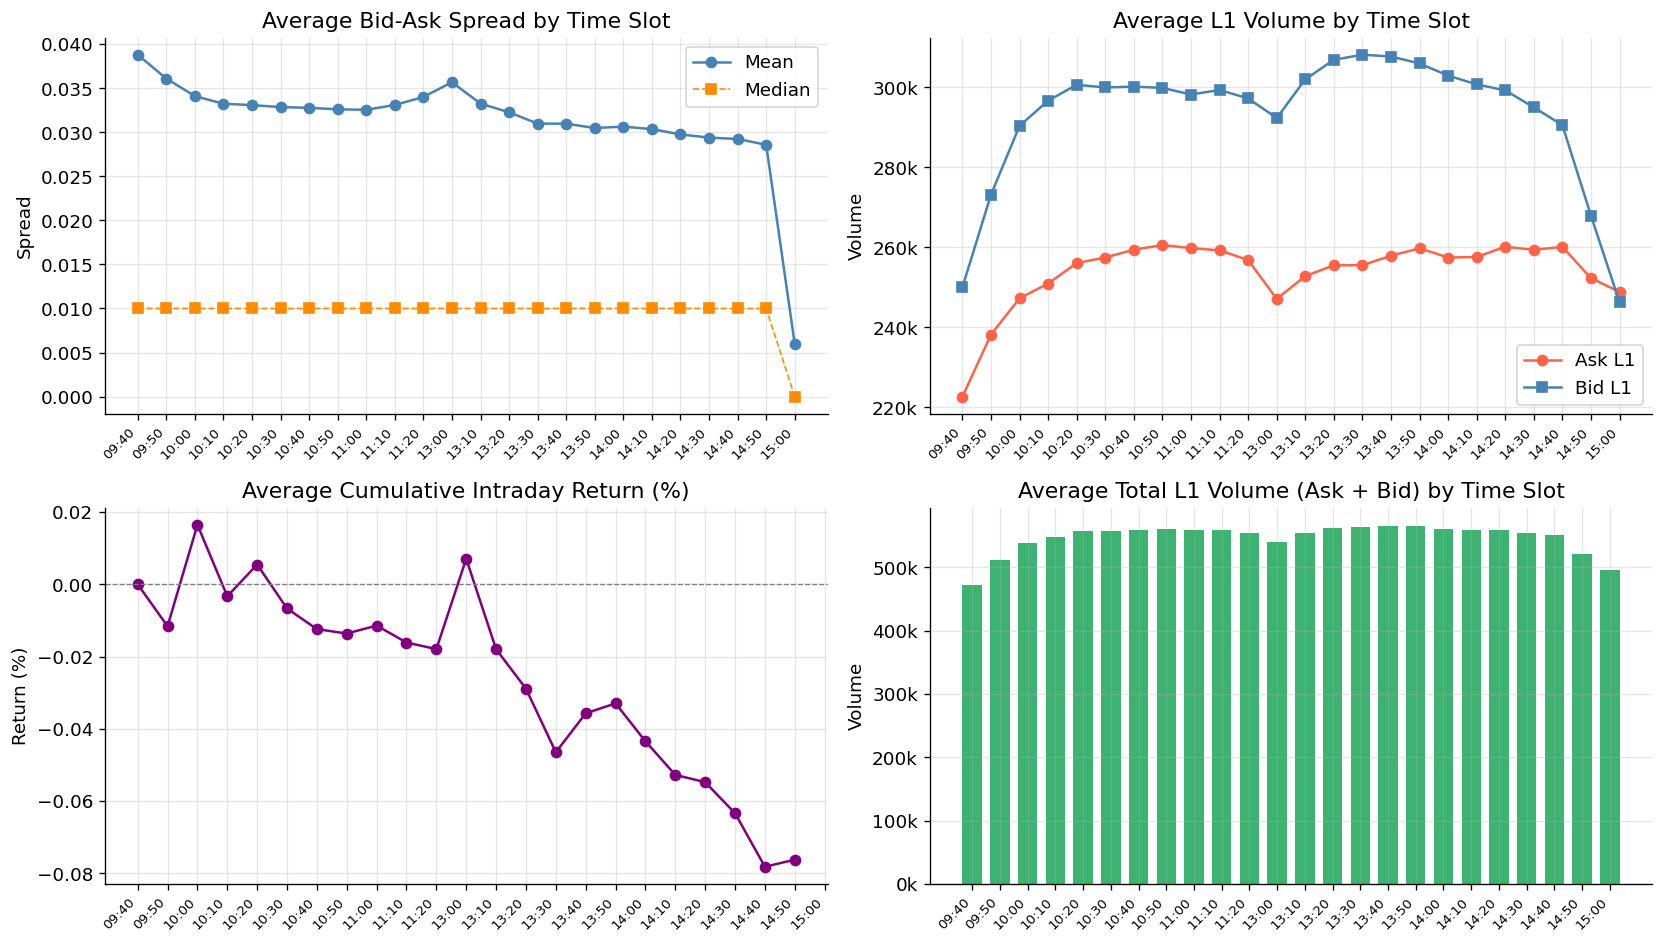

In [17]:
# Per time-slot aggregates across all assets and days
intraday = (
    lob.groupby("time")
    .agg(
        spread_mean=("spread", "mean"),
        spread_median=("spread", "median"),
        ask_vol1_mean=("ask_volume_1", "mean"),
        bid_vol1_mean=("bid_volume_1", "mean"),
        mid_mean=("mid_price", "mean"),
    )
    .loc[intraday_ts]
)  # enforce chronological order

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

ts_labels = [t[:5] for t in intraday_ts]  # 'HH:MM'
x = range(len(intraday_ts))

# Spread intraday
axes[0, 0].plot(x, intraday["spread_mean"], "o-", lw=1.5, label="Mean", color="steelblue")
axes[0, 0].plot(x, intraday["spread_median"], "s--", lw=1, label="Median", color="darkorange")
axes[0, 0].set_title("Average Bid-Ask Spread by Time Slot")
axes[0, 0].set_ylabel("Spread")
axes[0, 0].legend()
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(ts_labels, rotation=45, ha="right", fontsize=8)

# Ask / Bid L1 volume
axes[0, 1].plot(x, intraday["ask_vol1_mean"], "o-", lw=1.5, label="Ask L1", color="tomato")
axes[0, 1].plot(x, intraday["bid_vol1_mean"], "s-", lw=1.5, label="Bid L1", color="steelblue")
axes[0, 1].set_title("Average L1 Volume by Time Slot")
axes[0, 1].set_ylabel("Volume")
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}k"))
axes[0, 1].legend()
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(ts_labels, rotation=45, ha="right", fontsize=8)

# Mid-price intraday return
# Compute average log return from first slot to each slot across all (asset, day) pairs
lob_sorted = lob.sort_values(["asset_id", "trade_day_id", "time"])
lob_sorted["log_mid"] = np.log(lob_sorted["mid_price"])
first_mid = lob_sorted.groupby(["asset_id", "trade_day_id"])["log_mid"].transform("first")
lob_sorted["cum_ret"] = lob_sorted["log_mid"] - first_mid
avg_cum_ret = lob_sorted.groupby("time")["cum_ret"].mean().loc[intraday_ts]

axes[1, 0].plot(x, avg_cum_ret.values * 100, "o-", lw=1.5, color="purple")
axes[1, 0].axhline(0, color="grey", lw=0.8, ls="--")
axes[1, 0].set_title("Average Cumulative Intraday Return (%)")
axes[1, 0].set_ylabel("Return (%)")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(ts_labels, rotation=45, ha="right", fontsize=8)

# Total volume (ask + bid L1)
intraday["total_vol1"] = intraday["ask_vol1_mean"] + intraday["bid_vol1_mean"]
axes[1, 1].bar(x, intraday["total_vol1"], color="mediumseagreen", width=0.7)
axes[1, 1].set_title("Average Total L1 Volume (Ask + Bid) by Time Slot")
axes[1, 1].set_ylabel("Volume")
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1e3:.0f}k"))
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(ts_labels, rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. Volume Structure & Order Imbalance

Order imbalance (OIB) at L1 captures the directional pressure from the book. A positive OIB indicates more aggressive buying interest; negative indicates selling pressure.

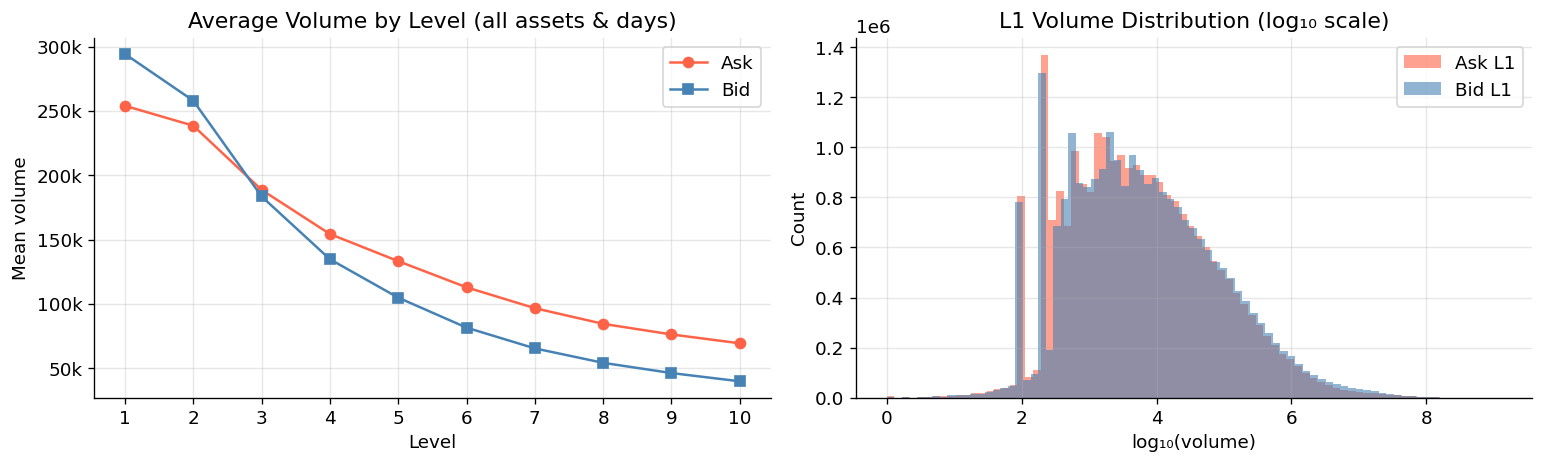

In [18]:
# Average volume at each level (bid vs ask)
avg_ask_vol = lob[ASK_VOL_COLS].mean()
avg_bid_vol = lob[BID_VOL_COLS].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(levels, avg_ask_vol.values, "o-", color="tomato", label="Ask")
axes[0].plot(levels, avg_bid_vol.values, "s-", color="steelblue", label="Bid")
axes[0].set_title("Average Volume by Level (all assets & days)")
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Mean volume")
axes[0].set_xticks(levels)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}k"))
axes[0].legend()

# Distribution of L1 ask volume (log scale)
ask_v1 = lob["ask_volume_1"].dropna()
ask_v1 = ask_v1[ask_v1 > 0]
axes[1].hist(np.log10(ask_v1), bins=80, color="tomato", alpha=0.6, label="Ask L1")
bid_v1 = lob["bid_volume_1"].dropna()
bid_v1 = bid_v1[bid_v1 > 0]
axes[1].hist(np.log10(bid_v1), bins=80, color="steelblue", alpha=0.6, label="Bid L1")
axes[1].set_title("L1 Volume Distribution (log₁₀ scale)")
axes[1].set_xlabel("log₁₀(volume)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

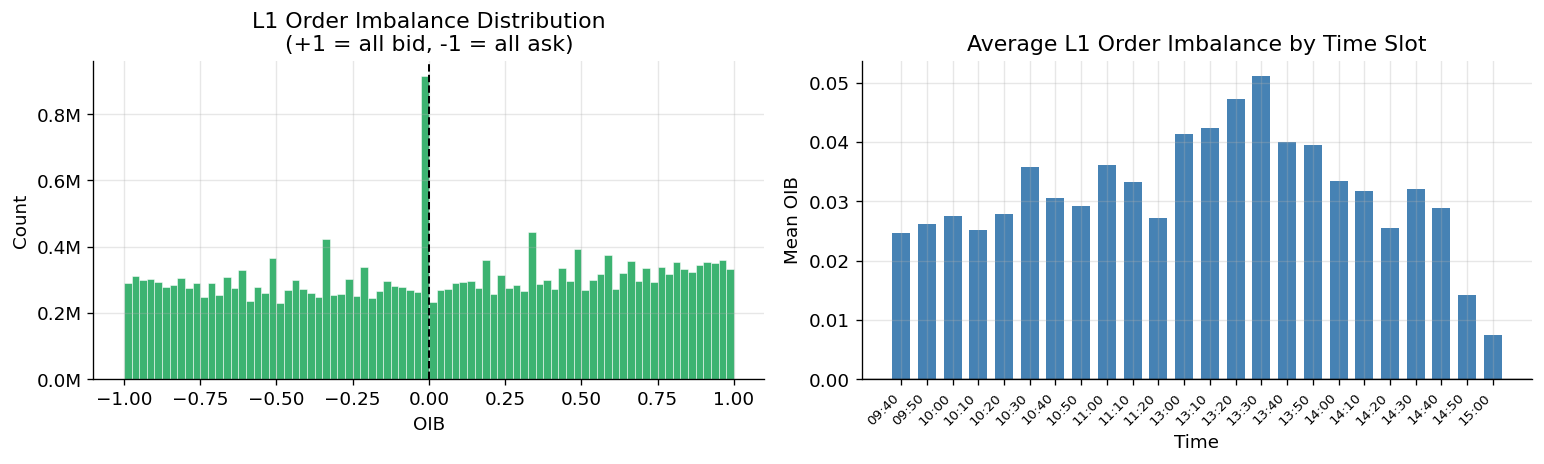

OIB — mean: 0.0322  std: 0.5785  median: 0.0290


In [19]:
# Order Imbalance at L1
denom = lob["bid_volume_1"] + lob["ask_volume_1"]
lob["oib_l1"] = (lob["bid_volume_1"] - lob["ask_volume_1"]) / denom
# OIB ∈ [-1, +1]: +1 = all volume on bid, -1 = all volume on ask

valid_oib = lob["oib_l1"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(valid_oib, bins=80, color="mediumseagreen", edgecolor="white", lw=0.3)
axes[0].axvline(0, color="black", lw=1.2, ls="--")
axes[0].set_title("L1 Order Imbalance Distribution\n(+1 = all bid, -1 = all ask)")
axes[0].set_xlabel("OIB")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1e6:.1f}M"))

# OIB by time of day
oib_by_time = lob.groupby("time")["oib_l1"].mean().loc[intraday_ts]
colors = ["tomato" if v < 0 else "steelblue" for v in oib_by_time.values]
axes[1].bar(range(len(intraday_ts)), oib_by_time.values, color=colors, width=0.7)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Average L1 Order Imbalance by Time Slot")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Mean OIB")
axes[1].set_xticks(range(len(intraday_ts)))
axes[1].set_xticklabels(ts_labels, rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

print(
    f"OIB — mean: {valid_oib.mean():.4f}  std: {valid_oib.std():.4f}  median: {valid_oib.median():.4f}"
)

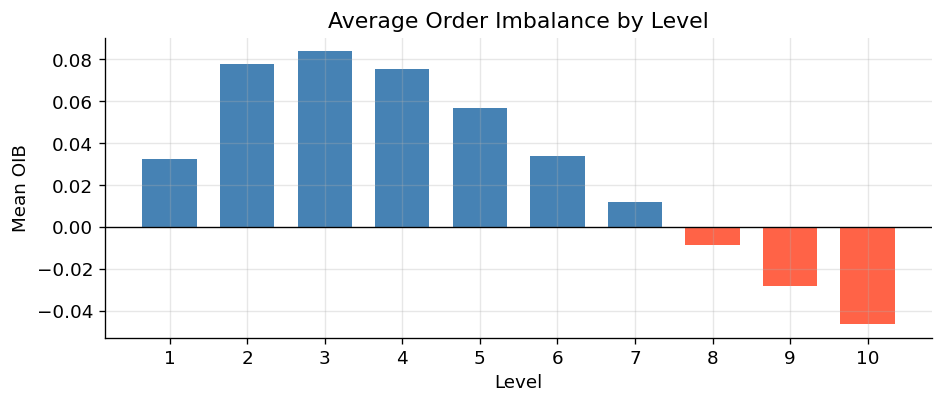

In [20]:
# Multi-level imbalance: compare imbalance across all 10 levels
oib_by_level = {}
for i in range(1, N_LEVELS + 1):
    bv = lob[f"bid_volume_{i}"]
    av = lob[f"ask_volume_{i}"]
    oib_by_level[i] = ((bv - av) / (bv + av)).mean()

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["tomato" if v < 0 else "steelblue" for v in oib_by_level.values()]
ax.bar(list(oib_by_level.keys()), list(oib_by_level.values()), color=colors, width=0.7)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Average Order Imbalance by Level")
ax.set_xlabel("Level")
ax.set_ylabel("Mean OIB")
ax.set_xticks(levels)
plt.tight_layout()
plt.show()

---
## 8. Price Level Spacing (Tick Structure)

The gap between consecutive price levels on the same side reveals the effective tick size and whether the book is clustered at round-number prices.

In [21]:
# For the sample snapshot: display exact level prices and increments
snap_df = pd.DataFrame(
    {
        "ask_price": ask_prices,
        "ask_vol": ask_vols,
        "bid_price": bid_prices,
        "bid_vol": bid_vols,
    },
    index=[f"L{i}" for i in range(1, N_LEVELS + 1)],
)

snap_df["ask_increment"] = snap_df["ask_price"].diff().shift(-1).abs()
snap_df["bid_increment"] = snap_df["bid_price"].diff().abs()

print(f"Snapshot — {ASSET_ID}  {DAY_ID}  {SNAP_TIME}")
print(snap_df.to_string())

Snapshot — A000568  D001  10:00:00
     ask_price  ask_vol  bid_price   bid_vol  ask_increment  bid_increment
L1        4.53  65200.0       4.52    9300.0           0.01            NaN
L2        4.54   3100.0       4.51   35400.0           0.01           0.01
L3        4.55  13300.0       4.50  131800.0           0.01           0.01
L4        4.56  12500.0       4.49   43000.0           0.01           0.01
L5        4.57  13400.0       4.48  157400.0           0.01           0.01
L6        4.58  29800.0       4.47   21000.0           0.01           0.01
L7        4.59  10000.0       4.46    5000.0           0.01           0.01
L8        4.60  38000.0       4.45   97800.0           0.01           0.01
L9        4.61  16400.0       4.44   27900.0           0.01           0.01
L10       4.62  14800.0       4.43   33100.0            NaN           0.01


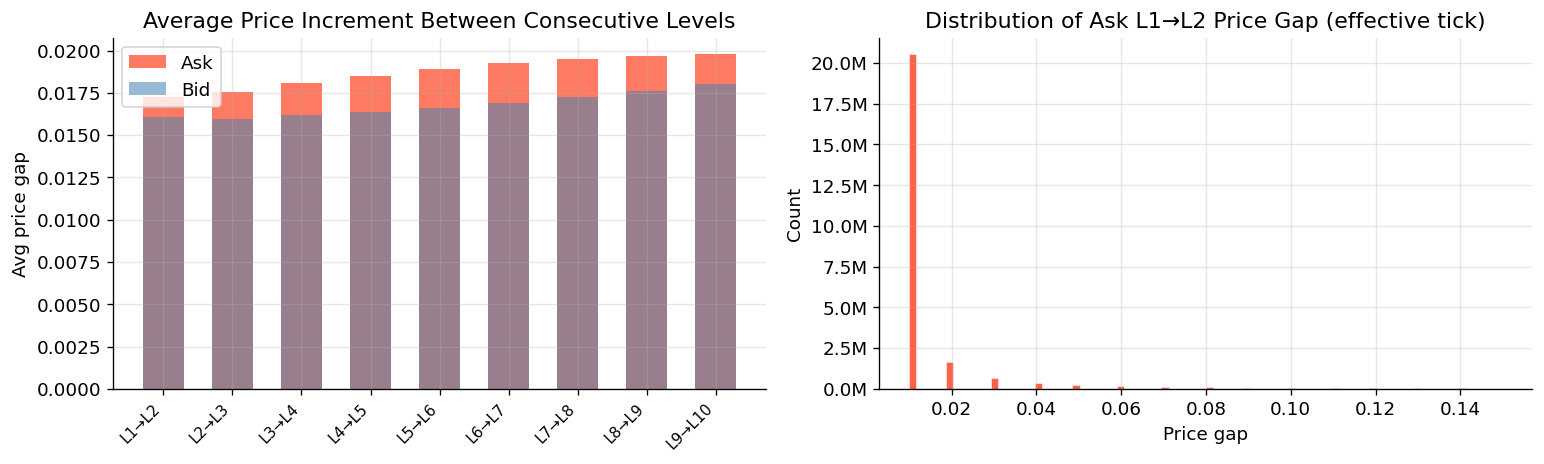

In [22]:
# Compute ask-side increments across all rows (L2 - L1, L3 - L2, …)
# Replace 0 with NaN first — zero means an empty level, not a valid price
ask_price_arr = lob[ASK_PRICE_COLS].values.astype(np.float64)
bid_price_arr = lob[BID_PRICE_COLS].values.astype(np.float64)
ask_price_arr[ask_price_arr == 0] = np.nan
bid_price_arr[bid_price_arr == 0] = np.nan

ask_increments = np.diff(ask_price_arr, axis=1)  # shape (N, 9), L(i+1) - L(i) > 0
bid_increments = np.diff(bid_price_arr, axis=1)  # bid decreases with level → negative

# Keep only well-ordered increments (ask L1 < L2 < …, bid L1 > L2 > …)
avg_ask_inc = np.nanmean(np.where(ask_increments > 0, ask_increments, np.nan), axis=0)
avg_bid_inc = np.nanmean(np.where(bid_increments < 0, np.abs(bid_increments), np.nan), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

gap_labels = [f"L{i}→L{i + 1}" for i in range(1, N_LEVELS)]
x9 = range(len(gap_labels))

axes[0].bar(x9, avg_ask_inc, color="tomato", width=0.6, label="Ask", alpha=0.85)
axes[0].bar(x9, avg_bid_inc, color="steelblue", width=0.6, alpha=0.55, label="Bid")
axes[0].set_title("Average Price Increment Between Consecutive Levels")
axes[0].set_xticks(x9)
axes[0].set_xticklabels(gap_labels, rotation=45, ha="right", fontsize=9)
axes[0].set_ylabel("Avg price gap")
axes[0].legend()

# Tick size distribution at L1 on ask side (L2 - L1), valid increments only
tick_l1 = ask_increments[:, 0]
tick_l1 = tick_l1[(tick_l1 > 0) & (tick_l1 < np.nanpercentile(tick_l1[tick_l1 > 0], 99))]
axes[1].hist(tick_l1, bins=80, color="tomato", edgecolor="white", lw=0.3)
axes[1].set_title("Distribution of Ask L1→L2 Price Gap (effective tick)")
axes[1].set_xlabel("Price gap")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1e6:.1f}M"))

plt.tight_layout()
plt.show()

---
## 9. Daily Data EDA

OHLCV-level analysis: return distribution, intraday price range, trading activity, and cross-feature correlations.

In [23]:
print("Daily data stats")
daily.describe().T

Daily data stats


,count,mean,std,min,25%,50%,75%,max
open,1060121.0,25.570643,53.714288,0.230,6.910000,13.450000,26.700000,2.055000e+03
high,1060121.0,26.119162,54.687024,0.300,7.020000,13.700000,27.250000,2.067770e+03
low,1060121.0,25.061570,52.794948,0.130,6.810000,13.220000,26.180000,2.015210e+03
close,1060121.0,25.562947,53.699327,0.290,6.910000,13.450000,26.690000,2.033010e+03
volume,1060121.0,141960.078476,336648.968047,81.000,18762.960000,50026.130000,135154.740000,2.404267e+07
amount,1060121.0,169052.257921,365054.537843,47.684,30173.320000,66216.540000,162830.518000,2.021758e+07
adj_factor,1060121.0,1.069674,0.178383,1.000,1.004286,1.011389,1.031447,4.000000e+00
vwap_0930_0935,1060121.0,25.559708,53.699127,0.000,6.909823,13.447584,26.687887,2.061560e+03


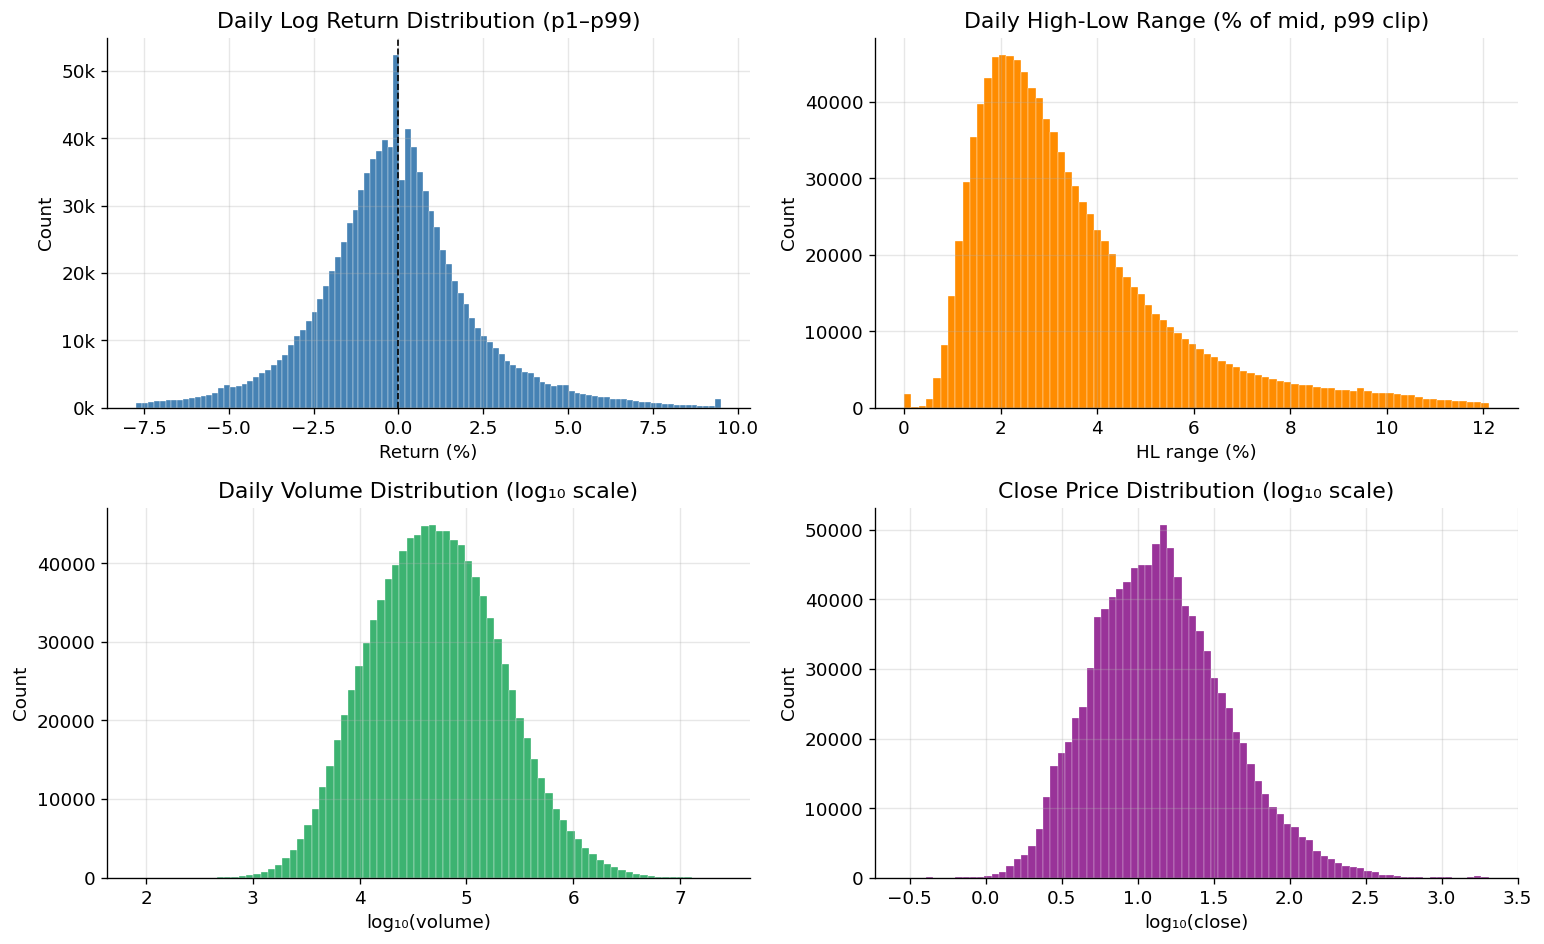

In [24]:
# Daily log returns per asset
daily_sorted = daily.sort_values(["asset_id", "trade_day_id"])
daily_sorted["log_ret"] = daily_sorted.groupby("asset_id")["close"].transform(
    lambda s: np.log(s).diff()
)

# High-low range as fraction of mid
daily_sorted["hl_range"] = (daily_sorted["high"] - daily_sorted["low"]) / (
    (daily_sorted["high"] + daily_sorted["low"]) / 2
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Return distribution
rets = daily_sorted["log_ret"].dropna()
p01, p99 = rets.quantile(0.01), rets.quantile(0.99)
rets_clip = rets[(rets > p01) & (rets < p99)]
axes[0, 0].hist(rets_clip * 100, bins=100, color="steelblue", edgecolor="white", lw=0.2)
axes[0, 0].axvline(0, color="black", lw=1, ls="--")
axes[0, 0].set_title("Daily Log Return Distribution (p1–p99)")
axes[0, 0].set_xlabel("Return (%)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}k"))

# High-low range
hl = daily_sorted["hl_range"].dropna()
hl = hl[hl < hl.quantile(0.99)]
axes[0, 1].hist(hl * 100, bins=80, color="darkorange", edgecolor="white", lw=0.2)
axes[0, 1].set_title("Daily High-Low Range (% of mid, p99 clip)")
axes[0, 1].set_xlabel("HL range (%)")
axes[0, 1].set_ylabel("Count")

# Volume distribution (log)
vol = daily_sorted["volume"].dropna()
vol = vol[vol > 0]
axes[1, 0].hist(np.log10(vol), bins=80, color="mediumseagreen", edgecolor="white", lw=0.2)
axes[1, 0].set_title("Daily Volume Distribution (log₁₀ scale)")
axes[1, 0].set_xlabel("log₁₀(volume)")
axes[1, 0].set_ylabel("Count")

# Close price distribution (log)
close = daily_sorted["close"].dropna()
close = close[close > 0]
axes[1, 1].hist(np.log10(close), bins=80, color="purple", edgecolor="white", lw=0.2, alpha=0.8)
axes[1, 1].set_title("Close Price Distribution (log₁₀ scale)")
axes[1, 1].set_xlabel("log₁₀(close)")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

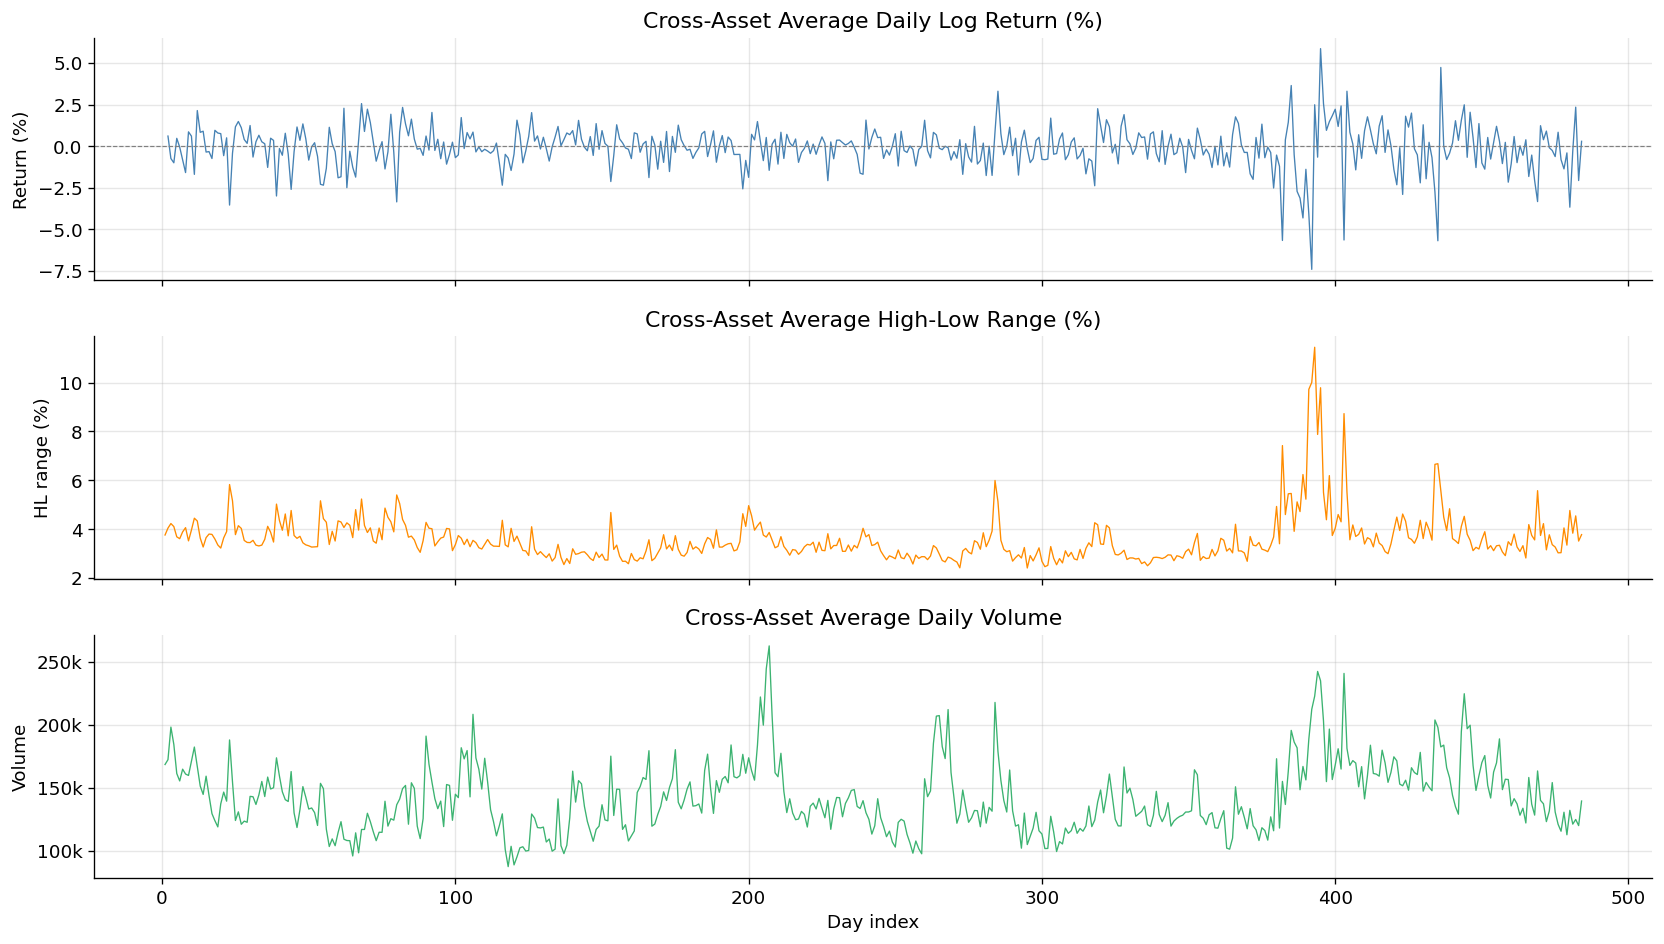

In [25]:
# Average daily return and HL range over time
daily_sorted["day_num"] = daily_sorted["trade_day_id"].str[1:].astype(int)
agg_by_day = (
    daily_sorted.groupby("day_num")
    .agg(
        mean_ret=("log_ret", "mean"),
        mean_range=("hl_range", "mean"),
        mean_vol=("volume", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(agg_by_day["day_num"], agg_by_day["mean_ret"] * 100, lw=0.8, color="steelblue")
axes[0].axhline(0, color="grey", lw=0.7, ls="--")
axes[0].set_title("Cross-Asset Average Daily Log Return (%)")
axes[0].set_ylabel("Return (%)")

axes[1].plot(agg_by_day["day_num"], agg_by_day["mean_range"] * 100, lw=0.8, color="darkorange")
axes[1].set_title("Cross-Asset Average High-Low Range (%)")
axes[1].set_ylabel("HL range (%)")

axes[2].plot(agg_by_day["day_num"], agg_by_day["mean_vol"], lw=0.8, color="mediumseagreen")
axes[2].set_title("Cross-Asset Average Daily Volume")
axes[2].set_ylabel("Volume")
axes[2].set_xlabel("Day index")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}k"))

plt.tight_layout()
plt.show()

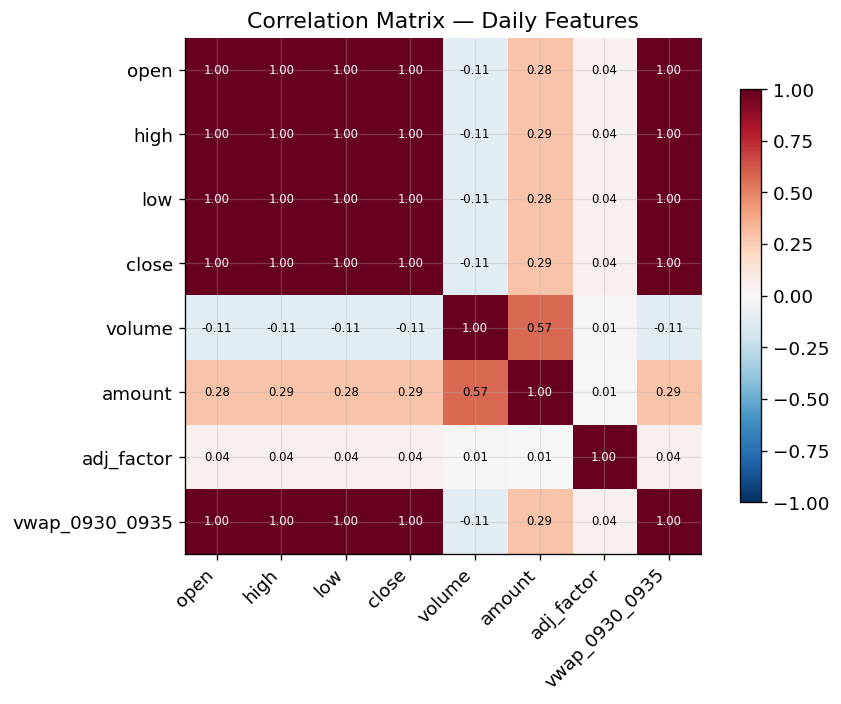

In [26]:
# Correlation matrix of daily features
daily_feats = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "amount",
    "adj_factor",
    "vwap_0930_0935",
]
corr = daily[daily_feats].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(daily_feats)))
ax.set_xticklabels(daily_feats, rotation=45, ha="right")
ax.set_yticks(range(len(daily_feats)))
ax.set_yticklabels(daily_feats)
ax.set_title("Correlation Matrix — Daily Features")
for i in range(len(daily_feats)):
    for j in range(len(daily_feats)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="white" if abs(corr.iloc[i, j]) > 0.6 else "black",
        )
plt.tight_layout()
plt.show()

---
## 10. Cross-Asset Overview

Distribution of key statistics aggregated at the asset level, to understand heterogeneity across the universe.

In [27]:
# Per-asset summary from LOB data
asset_stats = (
    lob.groupby("asset_id")
    .agg(
        n_obs=("mid_price", "count"),
        mean_mid=("mid_price", "mean"),
        mean_spread=("spread", "mean"),
        mean_rel_spread=("rel_spread", "mean"),
        mean_ask_vol1=("ask_volume_1", "mean"),
        mean_bid_vol1=("bid_volume_1", "mean"),
        mean_oib=("oib_l1", "mean"),
    )
    .reset_index()
)

print("Per-asset LOB stats summary:")
asset_stats[
    [
        "mean_mid",
        "mean_spread",
        "mean_rel_spread",
        "mean_ask_vol1",
        "mean_bid_vol1",
        "mean_oib",
    ]
].describe()

Per-asset LOB stats summary:


,mean_mid,mean_spread,mean_rel_spread,mean_ask_vol1,mean_bid_vol1,mean_oib
count,2270.000000,2270.000000,2270.000000,2.270000e+03,2.270000e+03,2270.000000
mean,25.986891,0.032432,0.001489,2.725382e+05,2.951857e+05,0.032044
std,50.817997,0.059261,0.000904,2.213086e+06,1.772697e+06,0.019868
min,1.161256,0.009891,0.000215,4.693175e+02,5.197572e+02,-0.050584
25%,7.211021,0.010307,0.000923,3.027697e+03,6.897109e+03,0.018783
50%,14.060851,0.012516,0.001243,1.176591e+04,3.984229e+04,0.032896
75%,28.258543,0.026337,0.001793,5.907530e+04,1.585998e+05,0.045411
max,1741.656250,1.116847,0.008608,6.430737e+07,4.950567e+07,0.122929


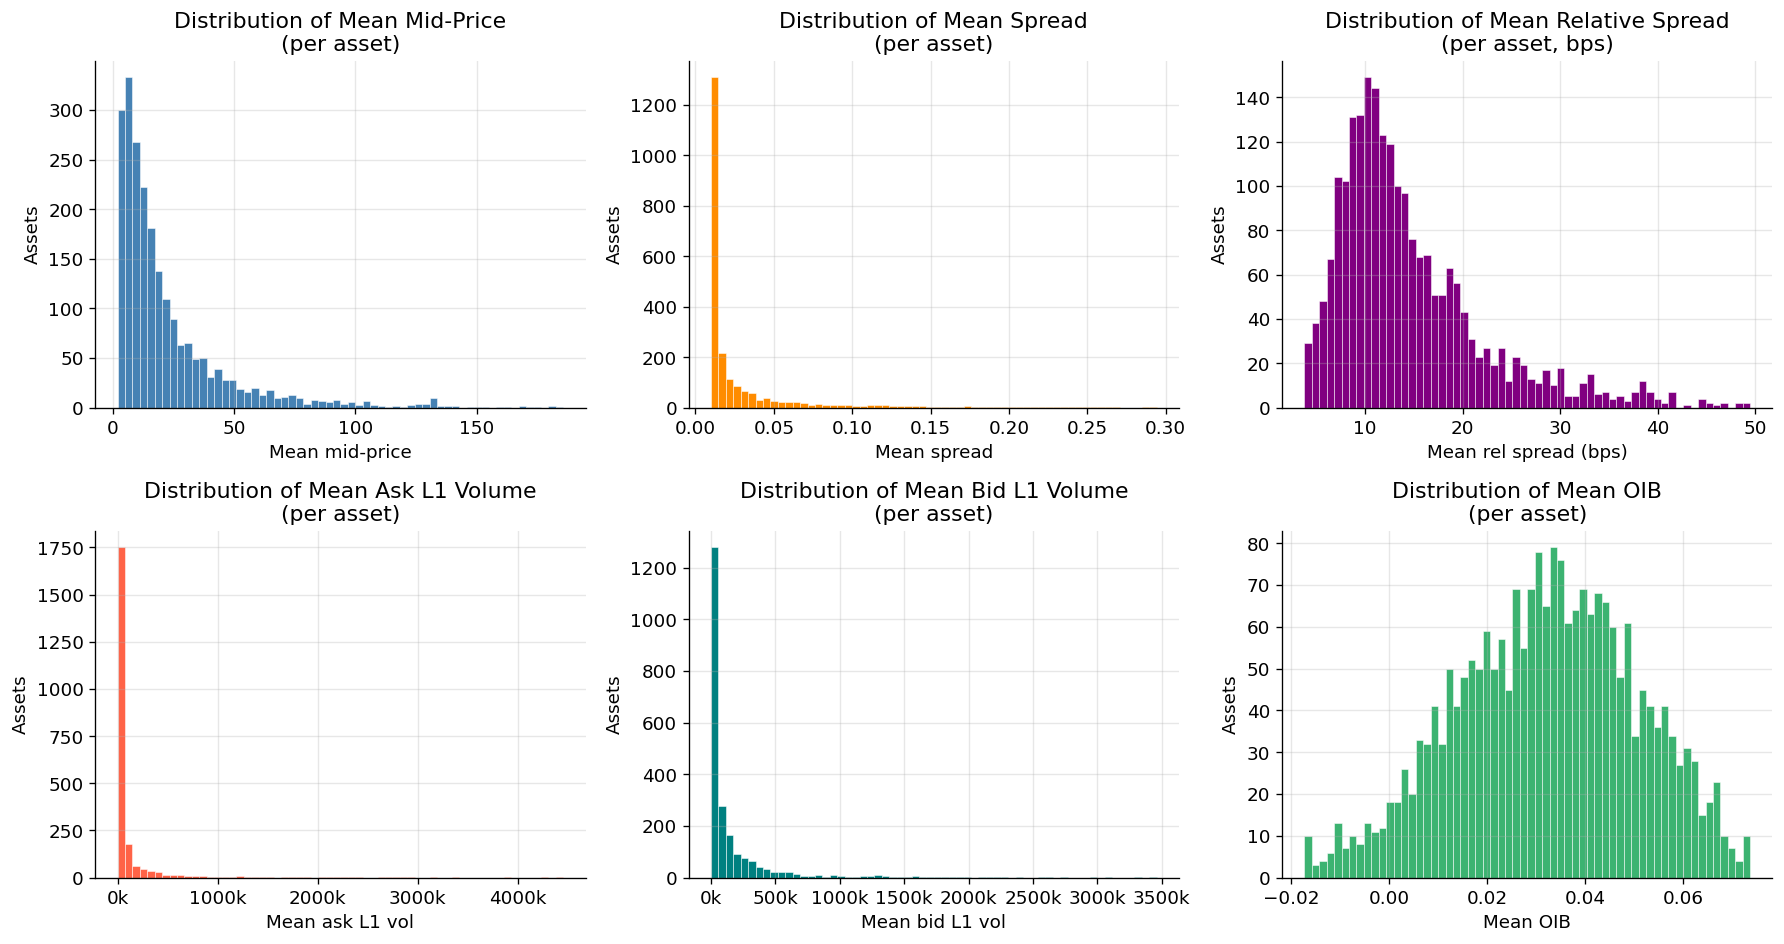

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))


def plot_hist(ax, series, title, xlabel, color, fmt=None):
    s = series.dropna()
    s = s[s < s.quantile(0.99)]
    s = s[s > s.quantile(0.01)]
    ax.hist(s, bins=60, color=color, edgecolor="white", lw=0.3)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Assets")
    if fmt:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt))


plot_hist(
    axes[0, 0],
    asset_stats["mean_mid"],
    "Distribution of Mean Mid-Price\n(per asset)",
    "Mean mid-price",
    "steelblue",
)

plot_hist(
    axes[0, 1],
    asset_stats["mean_spread"],
    "Distribution of Mean Spread\n(per asset)",
    "Mean spread",
    "darkorange",
)

plot_hist(
    axes[0, 2],
    asset_stats["mean_rel_spread"] * 1e4,
    "Distribution of Mean Relative Spread\n(per asset, bps)",
    "Mean rel spread (bps)",
    "purple",
)

plot_hist(
    axes[1, 0],
    asset_stats["mean_ask_vol1"],
    "Distribution of Mean Ask L1 Volume\n(per asset)",
    "Mean ask L1 vol",
    "tomato",
    fmt=lambda x, _: f"{x / 1e3:.0f}k",
)

plot_hist(
    axes[1, 1],
    asset_stats["mean_bid_vol1"],
    "Distribution of Mean Bid L1 Volume\n(per asset)",
    "Mean bid L1 vol",
    "teal",
    fmt=lambda x, _: f"{x / 1e3:.0f}k",
)

plot_hist(
    axes[1, 2],
    asset_stats["mean_oib"],
    "Distribution of Mean OIB\n(per asset)",
    "Mean OIB",
    "mediumseagreen",
)

plt.tight_layout()
plt.show()

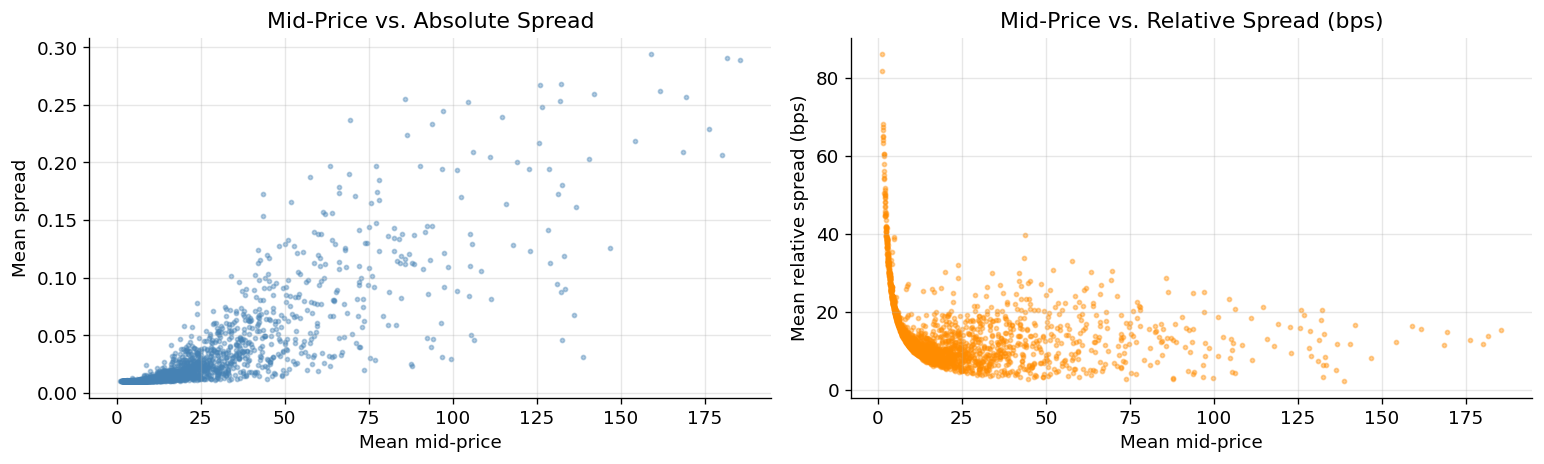

In [29]:
# Scatter: mid-price vs. spread — do expensive stocks have wider spreads?
clip = asset_stats[
    (asset_stats["mean_mid"] < asset_stats["mean_mid"].quantile(0.99))
    & (asset_stats["mean_spread"] < asset_stats["mean_spread"].quantile(0.99))
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(clip["mean_mid"], clip["mean_spread"], s=6, alpha=0.4, color="steelblue")
axes[0].set_title("Mid-Price vs. Absolute Spread")
axes[0].set_xlabel("Mean mid-price")
axes[0].set_ylabel("Mean spread")

axes[1].scatter(clip["mean_mid"], clip["mean_rel_spread"] * 1e4, s=6, alpha=0.4, color="darkorange")
axes[1].set_title("Mid-Price vs. Relative Spread (bps)")
axes[1].set_xlabel("Mean mid-price")
axes[1].set_ylabel("Mean relative spread (bps)")

plt.tight_layout()
plt.show()

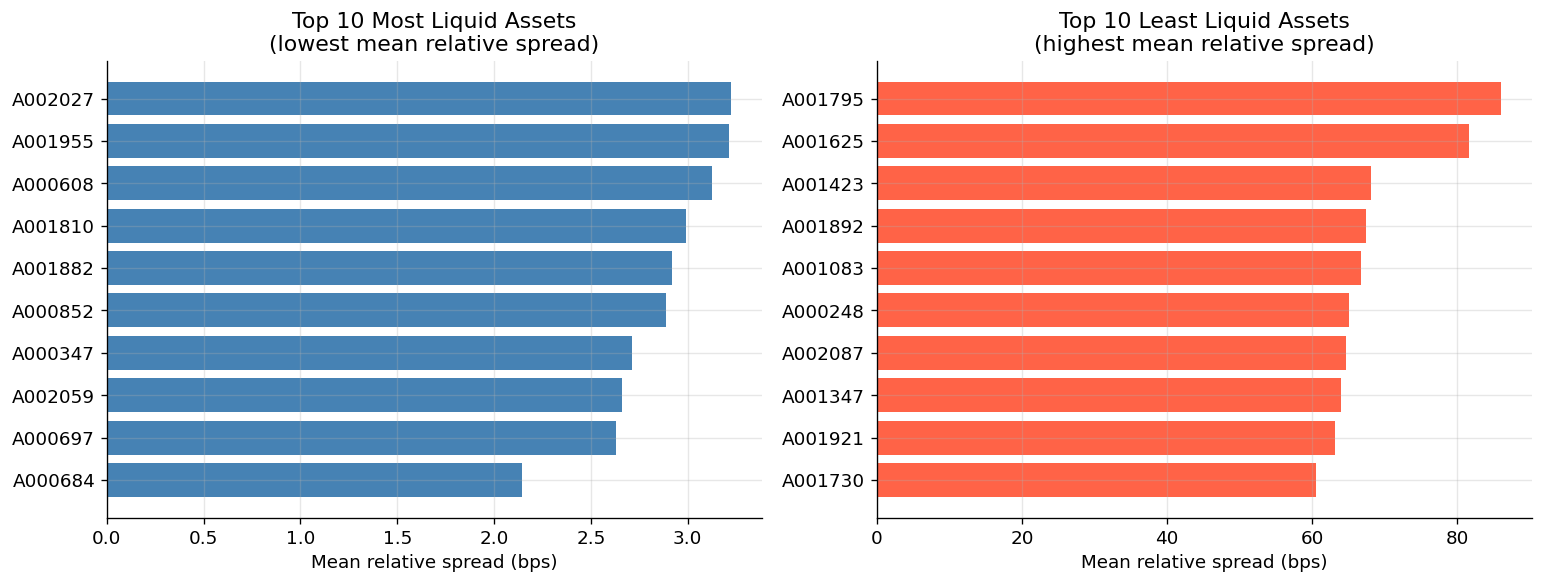

In [30]:
# Top / bottom 10 assets by relative spread (liquidity ranking)
asset_stats_sorted = asset_stats.sort_values("mean_rel_spread")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top10 = asset_stats_sorted.head(10)
bot10 = asset_stats_sorted.tail(10)

axes[0].barh(top10["asset_id"], top10["mean_rel_spread"] * 1e4, color="steelblue")
axes[0].set_title("Top 10 Most Liquid Assets\n(lowest mean relative spread)")
axes[0].set_xlabel("Mean relative spread (bps)")

axes[1].barh(bot10["asset_id"], bot10["mean_rel_spread"] * 1e4, color="tomato")
axes[1].set_title("Top 10 Least Liquid Assets\n(highest mean relative spread)")
axes[1].set_xlabel("Mean relative spread (bps)")

plt.tight_layout()
plt.show()